# Data Processing

Information about M3OCTA:
1. Four modalities: Retinal surface, retinal deep, choroid capillary, choroid large vessel
2. 24 x 20 mm^2
3. Five conditions: Normal, DR, DME, RVO, HBP, VH.
4. They are not divided by conditions like MPOS, but rather variety of combinations
5. Age range mostly 50-80
6. Resolution: 1536 x 1280
7. Number of images: 1637

Information of FFA-IR:

1. Sorted based on lesions rather than diseases
2. No standardised resolution given, will be resized to standard
3. Resolutions within range from 384 × 384 to 3216 × 2696

Information of MPOS:
Resolution: 1920 x 991

# UWOCTA Processing

Goal: Obtain surface modality only and filter them

In [31]:
import glob
import json

uwocta = {}

with open('ImageProcessing/UWOCTA/Dataset_published/train.json', 'r') as file:
    train = json.load(file)

with open('ImageProcessing/UWOCTA/Dataset_published/test.json', 'r') as file:
    test = json.load(file)

with open('ImageProcessing/UWOCTA/Dataset_published/val.json', 'r') as file:
    val = json.load(file)

for i, v in train.items():
    uwocta.update({i: v})

for j, v in test.items():
    uwocta.update({j: v})

for k, v in val.items():
    uwocta.update({k: v})

with open('ImageProcessing/UWOCTA/Dataset_published/combineduwocta.json', 'w', encoding='utf-8') as file:
    json.dump(uwocta, file, indent=4)

In [32]:
with open('ImageProcessing/UWOCTA/Dataset_published/combineduwocta.json', 'r') as file:
    uwocta = json.load(file)

In [33]:
paths = {}
#If diagnosis has no HBP or VH, save path
#{Path:, Label:, ID:}, key is path

for patient, info in uwocta.items():
    iden = patient
    for item, value in info.items():
        if item != 'ID':
            label = []
            path = ''
            for var, dx in value.items():
                if var == 'Label':
                    label = dx
                elif var == 'Paths':
                    for modal, loc in dx.items():
                        if modal == 'surface':
                            path = loc.replace("\\", "/")
            if path != '' and label != []:
                for i in range(0, 3):
                    if label[i] == None:
                        label[i] = 0
                add = {
                    'label': label,
                    'ID': iden
                }
                paths[path] = add

In [7]:
normal = 0
rvo = 0
dr = 0

for patient, info in uwocta.items():
    iden = patient
    for item, value in info.items():
        if item != 'ID':
            for var, dx in value.items():
                if var == 'Label':
                    if 1 in dx:
                        if dx[2] == 1:
                            rvo += 1
                        elif dx[0] == 1:
                            dr += 1
                    else:
                        normal += 1

print('Normal: ', normal)
print('RVO: ', rvo)
print('DR: ', dr)

Normal:  542
RVO:  125
DR:  515


In [34]:
paths

{'patients/20221229173526/Right/surface.png': {'label': [0, 0, 0, 0, 0],
  'ID': '20221229173526'},
 'patients/20221229173526/Right1/surface.png': {'label': [0, 0, 0, 0, 0],
  'ID': '20221229173526'},
 'patients/20230202113443/Right/surface.png': {'label': [0, 1, 1, 0, 0],
  'ID': '20230202113443'},
 'patients/20230202113443/Right1/surface.png': {'label': [0, 1, 1, 0, 0],
  'ID': '20230202113443'},
 'patients/20230727170249/Right/surface.png': {'label': [0, 0, 0, 0, 0],
  'ID': '20230727170249'},
 'patients/20230622083338/Left/surface.png': {'label': [0, 1, 0, 0, 0],
  'ID': '20230622083338'},
 'patients/20230622083338/Right/surface.png': {'label': [0, 1, 0, 0, 0],
  'ID': '20230622083338'},
 'patients/20230622083338/Right1/surface.png': {'label': [0, 1, 0, 0, 0],
  'ID': '20230622083338'},
 'patients/20230312115255/Right/surface.png': {'label': [1, 1, 0, 1, 0],
  'ID': '20230312115255'},
 'patients/20230312115255/Right1/surface.png': {'label': [1, 1, 0, 1, 0],
  'ID': '20230312115255'

In [35]:
len(paths)

1310

In [10]:
from pathlib import Path

folder_name = 'selectedUWOCTA'
Path(folder_name).mkdir(parents=True, exist_ok=True)

New image file title format:
patientid_side.png

In [3]:
import shutil
import os

base = 'ImageProcessing/UWOCTA/Dataset_published/'
folder = 'ImageProcessing/selectedUWOCTA/'

for path, info in paths.items():
    comps = path.split('/')
    img = comps[1] + '_' + comps[2] + '.png'
    dest = folder + img
    source = base + path
    print('source: ', source)
    shutil.copy2(source, dest)
    print('dest: ', dest)

source:  UWOCTA/Dataset_published/patients/20221229173526/Right/surface.png
dest:  selectedUWOCTA/20221229173526_Right.png
source:  UWOCTA/Dataset_published/patients/20221229173526/Right1/surface.png
dest:  selectedUWOCTA/20221229173526_Right1.png
source:  UWOCTA/Dataset_published/patients/20230202113443/Right/surface.png
dest:  selectedUWOCTA/20230202113443_Right.png
source:  UWOCTA/Dataset_published/patients/20230202113443/Right1/surface.png
dest:  selectedUWOCTA/20230202113443_Right1.png
source:  UWOCTA/Dataset_published/patients/20230727170249/Right/surface.png
dest:  selectedUWOCTA/20230727170249_Right.png
source:  UWOCTA/Dataset_published/patients/20230622083338/Left/surface.png
dest:  selectedUWOCTA/20230622083338_Left.png
source:  UWOCTA/Dataset_published/patients/20230622083338/Right/surface.png
dest:  selectedUWOCTA/20230622083338_Right.png
source:  UWOCTA/Dataset_published/patients/20230622083338/Right1/surface.png
dest:  selectedUWOCTA/20230622083338_Right1.png
source:  UWO

In [17]:
from pathlib import Path

p = Path('ImageProcessing/selectedUWOCTA')

count = len([item for item in p.iterdir() if item.is_file()])
print(count)

1310


In [36]:
chosen = {}

for path, info in paths.items():
    comps = path.split('/')
    img = comps[1] + '_' + comps[2] + '.png'
    chosen[img] = info['label']

chosen

with open('uwocta.json', 'w') as file:
    json.dump(chosen, file, indent=4)

Standard the sizes first for easier processing

In [33]:
import cv2
import os
from pathlib import Path

source = 'ImageProcessing/selectedUWOCTA'
dest = 'ImageProcessing/256UWOCTA'

for img in Path(source).iterdir():
    if img.suffix == '.png':
        # print(os.path.basename(img))
        image = cv2.imread(img)
        resized = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)
        resized = cv2.normalize(resized, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
        cv2.imwrite(os.path.join(dest, os.path.basename(img)), resized)

Reading images from /home/FYP/tsajoto001/OCTA/256UWOCTA
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing scores:   0%|          | 0/1378 [00:00<?, ?it/s]

Computing hashes:   0%|          | 0/1378 [00:00<?, ?it/s]

Issue checks completed. 124 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | exact_duplicates |          110 |
|  1 | grayscale        |           12 |
|  2 | near_duplicates  |            2 |
|  3 | dark             |            0 |
|  4 | light            |            0 |
|  5 | blurry           |            0 |
|  6 | low_information  |            0 |
|  7 | odd_aspect_ratio |            0 |
|  8 | odd_size         |            0 | 

----------------- exact_duplicates images ------------------

Number of examples with this issue: 110
Examples representing most severe instances of this issue:

Set: 0


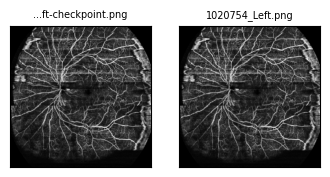

Set: 1


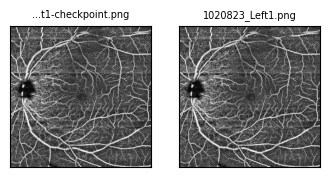

Set: 2


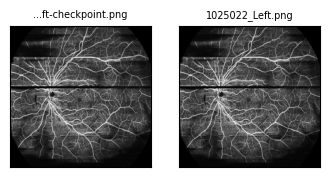

Set: 3


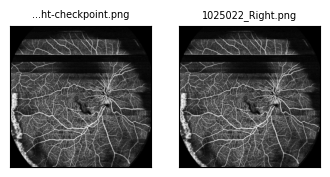

--------------------- grayscale images ---------------------

Number of examples with this issue: 12
Examples representing most severe instances of this issue:



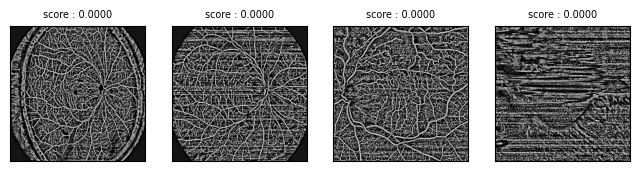

------------------ near_duplicates images ------------------

Number of examples with this issue: 2
Examples representing most severe instances of this issue:

Set: 0


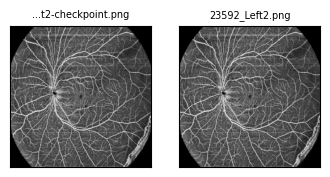

In [34]:
from cleanvision import Imagelab

path = 'ImageProcessing/256UWOCTA'
imagelab = Imagelab(data_path = path)
imagelab.find_issues()
imagelab.report()

Usual image issues like blurriness not present, however speckle noise, motion and edge artifects and gaussian noise are present

The motion artifact of dark patches in the image can be solved by the Contrast Limited Adaptive Histogram Equalization algorithm

In [35]:
import shutil
import os
from pathlib import Path
import cv2

clahe = cv2.createCLAHE(tileGridSize=(20,20))

home = 'ImageProcessing/256UWOCTA'
for image in Path(home).iterdir():
    if image.suffix == '.png':
        img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
        cimg = clahe.apply(img)
        blur = cimg.copy()
        blur = cv2.GaussianBlur(blur, (0, 0), 2.0)
        unsharp = cv2.addWeighted(cimg, 1.5, blur, -1.0, 0)
        cv2.imwrite(image, unsharp)

Afterwards, corrupted images are deleted. 

In [21]:
uwocta

{'20221229173526_Right.png': [0, 0, 0, 0, 0],
 '20221229173526_Right1.png': [0, 0, 0, 0, 0],
 '20230202113443_Right1.png': [0, 1, 1, 0, 0],
 '20230727170249_Right.png': [0, 0, 0, 0, 0],
 '20230622083338_Left.png': [0, 1, 0, 0, 0],
 '20230622083338_Right.png': [0, 1, 0, 0, 0],
 '20230622083338_Right1.png': [0, 1, 0, 0, 0],
 '20230312115255_Right.png': [1, 1, 0, 1, 0],
 '20230312115255_Right1.png': [1, 1, 0, 1, 0],
 '20230518111635_Left.png': [1, 0, 0, 1, 0],
 '20230524085821_Left.png': [1, 1, 0, 0, 0],
 '20230524085821_Right.png': [1, 1, 0, 0, 0],
 '20230516142136_Left.png': [0, 0, 0, 0, 0],
 '20230516142136_Right.png': [0, 0, 0, 0, 0],
 '20230205131432_Left.png': [1, 0, 0, 0, 0],
 '20230205131432_Left1.png': [1, 0, 0, 0, 0],
 '20221229163535_Right.png': [0, 1, 1, 0, 0],
 '20221229163535_Right1.png': [0, 1, 1, 0, 0],
 '20230206172838_Right.png': [0, 1, 1, 1, 0],
 '20230206172838_Right1.png': [0, 1, 1, 1, 0],
 '20230315081712_Left.png': [1, 0, 0, 0, 0],
 '20230315081712_Left1.png': [1, 0

In [65]:
import cv2
import os
from pathlib import Path

source = 'ImageProcessing/256UWOCTA'

for img in Path(source).iterdir():
    if img.suffix == '.png':
        # print(os.path.basename(img))
        image = cv2.imread(img)
        resized = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)
        resized = cv2.normalize(resized, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
        cv2.imwrite(os.path.join(source, os.path.basename(img)), resized)

In [11]:
from pathlib import Path

p = Path('ImageProcessing/256UWOCTA')

uwoctacount = len([item for item in p.iterdir() if item.is_file()])
print('Number of UWOCTA images remaining:', uwoctacount)

Number of UWOCTA images remaining: 887


In [12]:
import json
import os

with open('uwocta.json', 'r') as file:
    uwocta = json.load(file)

newocta = {}

folder = 'ImageProcessing/256UWOCTA/'
for path, dx in uwocta.items():
    file = folder + path
    if os.path.isfile(file):
        newocta[path] = dx

uwocta = newocta
with open('uwocta.json', 'w') as file:
    json.dump(uwocta, file, indent=4)

In [14]:
normal = 0
rvo = 0
dr = 0

for image, dx in uwocta.items():
    if 1 in dx:
        if dx[2] == 1:
            rvo += 1
        elif dx[0] == 1:
            dr += 1
    else:
        normal += 1

print('Normal: ', normal)
print('RVO: ', rvo)
print('DR: ', dr)

Normal:  428
RVO:  54
DR:  318


More OCTA scans of RVO eyes were added to the dataset to reduce class imblance

In [ ]:
#for image in folder. 
#1. resize and normalize
#2. apply clahe
#create new folder to preserve og copy

In [73]:
from pathlib import Path

folder_name = 'ImageProcessing/addOCTAprocessing'
Path(folder_name).mkdir(parents=True, exist_ok=True)

In [93]:
import cv2
import os
from pathlib import Path

source = 'ImageProcessing/OCTADrFanNgo'
dest = 'ImageProcessing/addOCTAprocessing'

for img in Path(source).iterdir():
    if img.suffix == '.png':
        # print(os.path.basename(img))
        image = cv2.imread(img)
        resized = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)
        resized = cv2.normalize(resized, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
        cv2.imwrite(os.path.join(dest, os.path.basename(img)), resized)

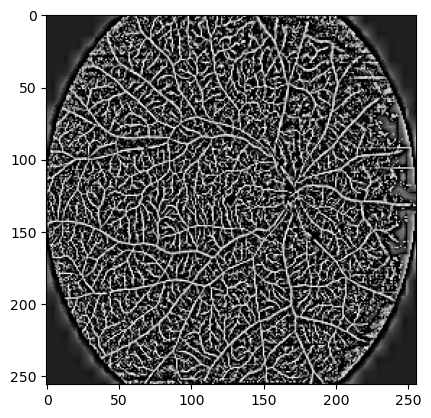

In [91]:
import matplotlib.pyplot as plt

clahe = cv2.createCLAHE(tileGridSize=(50,50))
clh2 = cv2.createCLAHE(tileGridSize=(30,30))

img = cv2.imread('ImageProcessing/addOCTAprocessing/AFK_OD_16-10-2025_10-20-14_Angio_Superficial.png', cv2.IMREAD_GRAYSCALE)
cimg = clahe.apply(img)
blur = cimg.copy()
blur = cv2.GaussianBlur(blur, (0, 0), 2.0)
unsharp = cv2.addWeighted(cimg, 1.5, blur, -1.0, 0)
c2img = clh2.apply(unsharp)
bl2 = c2img.copy()
bl2 = cv2.GaussianBlur(bl2, (0, 0), 2.0)
uns = cv2.addWeighted(c2img, 1.5, bl2, -1.0, 0)

plt.imshow(uns, cmap='grey')

In [94]:
import shutil
import os
from pathlib import Path
import cv2

clahe = cv2.createCLAHE(tileGridSize=(50,50))
clh2 = cv2.createCLAHE(tileGridSize=(30,30))

home = 'ImageProcessing/addOCTAprocessing'
for image in Path(home).iterdir():
    if image.suffix == '.png':
        img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
        cimg = clahe.apply(img)
        blur = cimg.copy()
        blur = cv2.GaussianBlur(blur, (0, 0), 2.0)
        unsharp = cv2.addWeighted(cimg, 1.5, blur, -1.0, 0)
        c2img = clh2.apply(unsharp)
        bl2 = c2img.copy()
        bl2 = cv2.GaussianBlur(bl2, (0, 0), 2.0)
        uns = cv2.addWeighted(c2img, 1.5, bl2, -1.0, 0)
        cv2.imwrite(image, uns)

Some images are cropped, and corrupted ones deleted

In [95]:
import cv2
import os
from pathlib import Path

source = 'ImageProcessing/addOCTAprocessing'
dest = 'ImageProcessing/256UWOCTA'

for img in Path(source).iterdir():
    if img.suffix == '.png':
        # print(os.path.basename(img))
        image = cv2.imread(img)
        resized = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)
        resized = cv2.normalize(resized, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
        cv2.imwrite(os.path.join(dest, os.path.basename(img)), resized)

Update uwocta.json to include these images. They are to have RVO marked

In [97]:
import json
import os
from pathlib import Path

folder = 'ImageProcessing/addOCTAprocessing'

with open('ImageProcessing/uwocta.json', 'r') as file:
    uwocta = json.load(file)

for img in Path(source).iterdir():
    if img.suffix == '.png':
        uwocta[os.path.basename(img)] = [0, 0, 1, 0, 0]

# print(uwocta['AFK_OS_16-10-2025_10-18-51_Angio_SVP.png'])

with open('ImageProcessing/uwocta.json', 'w') as file:
    json.dump(uwocta, file, indent=4)

[0, 0, 1, 0, 0]


In [4]:
import json
with open('ImageProcessing/uwocta.json', 'r') as file:
    uwocta = json.load(file)

octanormal = 0
octarvo = 0
octadr = 0

for image, dx in uwocta.items():
    if 1 in dx:
        if dx[2] == 1:
            octarvo += 1
        elif dx[0] == 1:
            octadr += 1
    else:
        octanormal += 1

print('Normal: ', octanormal)
print('RVO: ', octarvo)
print('DR: ', octadr)

Normal:  428
RVO:  104
DR:  318


In [6]:
from pathlib import Path

p = Path('ImageProcessing/256UWOCTA')

uwoctacount = len([item for item in p.iterdir() if item.is_file()])
print('Number of UWOCTA images:', uwoctacount)

Number of UWOCTA images: 937


# FFA Processing

In [4]:
from pathlib import Path

folder_name = 'ImageProcessing/selectedFFA'
Path(folder_name).mkdir(parents=True, exist_ok=True)

In [5]:
from pathlib import Path

p = Path('ImageProcessing/FFA/0_Normal')

count = len([item for item in p.iterdir() if item.is_file()])
print(count)

56


Crop out text

243.2


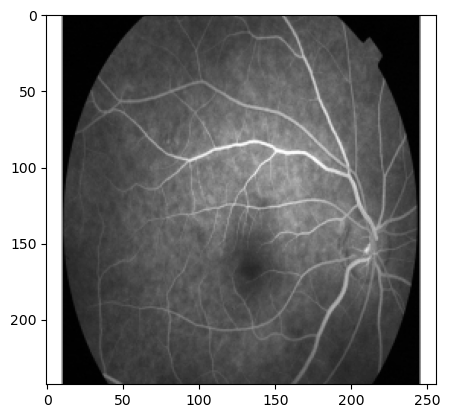

In [8]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread('ImageProcessing/256FFA/5.png')

#width: img.shape[1]
#height of text: img.shape[0] * 0.92 
y_end = img.shape[0] * 0.95
x_end = img.shape[1]

print(y_end)

cropped = img[0:int(y_end), 0:int(x_end)]
plt.imshow(cropped)

In [9]:
import shutil
from pathlib import Path
import cv2

base = 'ImageProcessing/FFA/0_Normal'
dest = 'ImageProcessing/selectedFFA'
src = Path(base)

for image in src.iterdir():
    # 1. create new file name
    file = str(Path(image).name)
    target = dest + '/' + file
    # print(target)
    #2. Crop image
    img = cv2.imread(image)
    y_end = img.shape[0] * 0.95
    x_end = img.shape[1]
    cropped = img[0:int(y_end), 0:int(x_end)]
    cv2.imwrite(target, cropped)

In [10]:
def largest_rect_in_histogram(hist):
    stack = []
    max_area = 0
    best = (0, 0, 0)
    for i, height in enumerate(hist):
        left = i
        while stack and stack[-1][1] > height:
            idx, h_val = stack.pop()
            width = i - idx
            area = h_val * width
            if area > max_area:
                max_area = area
                best = (h_val, idx, width)
            left = idx
        stack.append((left, height))
    for left, h_val in stack:
        width = len(hist) - left
        area = h_val * width
        if area > max_area:
            max_area = area
            best = (h_val, left, width)
    return max_area, best

In [12]:
import cv2
import numpy as np
import os
from pathlib import Path

source = 'ImageProcessing/DrFan_NgoFFA'
dest = 'ImageProcessing/selectedFFA'

for image in Path(source).iterdir():
    if image.suffix == '.png':
        img = cv2.imread(image)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        h, w = gray.shape
     
        blurred = cv2.GaussianBlur(gray, (21, 21), 0)
        _, mask = cv2.threshold(blurred, 15, 255, cv2.THRESH_BINARY)
     
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
     
        # Pick the largest component NOT touching the image border
        # (excludes white side-bars which always touch an edge)
        border_labels = set()
        border_labels.update(labels[0, :].tolist())
        border_labels.update(labels[-1, :].tolist())
        border_labels.update(labels[:, 0].tolist())
        border_labels.update(labels[:, -1].tolist())
        border_labels.discard(0)
     
        best_label = -1
        best_area = 0
        for label_id in range(1, num_labels):
            if label_id in border_labels:
                continue
            area = stats[label_id, cv2.CC_STAT_AREA]
            if area > best_area:
                best_area = area
                best_label = label_id
     
        if best_label == -1:
            print(f"Warning: no interior component found for {image.name}, using largest.")
            best_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
     
        clean_mask = np.zeros_like(mask)
        clean_mask[labels == best_label] = 255
     
        # Use CHAIN_APPROX_NONE to maximise the number of contour points —
        # fitEllipse requires at least 5. CHAIN_APPROX_SIMPLE can collapse
        # small/thin regions down to fewer than 5 points and cause a crash.
        contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        main_contour = max(contours, key=cv2.contourArea)
     
        # Guard: if still fewer than 5 points, retry with the globally largest component
        if len(main_contour) < 5:
            print(f"Warning: contour has only {len(main_contour)} points for {image.name}, retrying with largest component.")
            best_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            clean_mask = np.zeros_like(mask)
            clean_mask[labels == best_label] = 255
            contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            main_contour = max(contours, key=cv2.contourArea)
     
        if len(main_contour) < 5:
            print(f"Error: still fewer than 5 contour points for {image.name}, skipping.")
            continue
     
        ellipse = cv2.fitEllipse(main_contour)
     
        # Pure ellipse mask, no erosion
        ellipse_mask = np.zeros((h, w), dtype=np.uint8)
        cv2.ellipse(ellipse_mask, ellipse, 255, -1)
     
        best_rect_area = 0
        best_rect = None
        hist = np.zeros(w, dtype=np.int32)
        for row in range(h):
            hist = np.where(ellipse_mask[row] > 0, hist + 1, 0)
            area, (rect_h, rect_x, rect_w) = largest_rect_in_histogram(hist.tolist())
            if area > best_rect_area:
                best_rect_area = area
                best_rect = (rect_x, row - rect_h + 1, rect_w, rect_h)
        
        x, y, rw, rh = best_rect
        cropped = img[y:y+rh, x:x+rw]
        
        base = os.path.basename(image)
        base = base.replace('OCTA-RVO', '')
        base = base.replace(' ', '')
        cv2.imwrite(os.path.join(dest, base), cropped)
        # cv2.imwrite('cropped_interior_rect.png', cropped)

In [13]:
from pathlib import Path

p = Path('ImageProcessing/selectedFFA')

count = len([item for item in p.iterdir() if item.is_file()])
print(count)

99


In [1]:
import pandas as pd
df = pd.read_excel('ImageProcessing/lesions label.xlsx')
df.head()

,Unnamed: 0,count,疾病名称1,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,1.0,130,黄斑囊样水肿,cystoid macular edema,荧光积存,Pooling
1,2.0,114,弥漫性黄斑水肿,Difuse macula edema,荧光渗漏,Leakage
2,3.0,211,糖尿病性黄斑水肿,Diabetic macula edema,荧光渗漏,Leakage
3,3.1,2096,微血管瘤,microaneurysm,荧光渗漏,Leakage
4,3.2,464,无灌注区,non-perfusion area,充盈障碍,Filling defect


In [2]:
df.columns.values[0] = 'Lesion ID'
df.columns.values[3] = 'Name'

In [3]:
df

,Lesion ID,count,疾病名称1,Name,Unnamed: 4,Unnamed: 5
0,1.0,130,黄斑囊样水肿,cystoid macular edema,荧光积存,Pooling
1,2.0,114,弥漫性黄斑水肿,Difuse macula edema,荧光渗漏,Leakage
2,3.0,211,糖尿病性黄斑水肿,Diabetic macula edema,荧光渗漏,Leakage
3,3.1,2096,微血管瘤,microaneurysm,荧光渗漏,Leakage
4,3.2,464,无灌注区,non-perfusion area,充盈障碍,Filling defect
5,3.3,107,视网膜新生血管,retinal neovascularization,新生血管,Neovascularization
6,3.4,869,激光斑,laser spot,透见荧光,Transmitt
7,3.5,215,视网膜出血斑,Retinal haemorrhage spots,遮蔽荧光,Blocking Effect
8,3.6,213,微血管异常,Intraretinal microvascular abnormalities,荧光渗漏,Leakage
9,3.7,32,视网膜前出血,preretinal hemorrhage,遮蔽荧光,Blocking Effect


List of lesions that are eliminated due to having no association with the classes in M3OCTA:

1. Laser spot (3.4)
2. AMD (9)
3. pathologic myopic choroidal neovascularization (14.0)
4. high myopia with macular hemorrhage (18)
5. pathologic myopic macular degeneration with lacquer cracks (19)
6. pathologic myopic macular atrophy (20)
7. macular coloboma (27)
8. Best disease (6)
9. macular edema associated with retinitis pigmentosa (37)

1. Select all images w explicit disease/lesion in the M3OCTA classes (DME, CRVO + BRVO + ME w BRVO, Diffuse Macular Edema, Microaneurysm (DR))
2. Randomly select the rest

Dictionary format:

patient_imageno : [lesions]

In [1]:
import json

with open('ImageProcessing/FFAIR_2/lesion_info.json', 'r') as file:
    ffa = json.load(file)

In [16]:
rvo = 0
normal = 0

for patient, images in ffa.items():
    for image, lesions in images.items():
        for lesion in lesions:
            if lesion[0] == '4' or lesion[0] == '4.1' or lesion[0] == '4.2':
                rvo += 1
            elif lesion[0] == '0' or lesion[0] == '':
                normal += 1

print('RVO: ', rvo)
print('Normal: ', normal)

RVO:  479
Normal:  0


In [17]:
#add normal to final FFA
#reduce no of images from FFA-IR

In [3]:
count = 0

for patient, images in ffa.items():
    for image, lesions in images.items():
        count = count + 1

print(count)

4967


In [18]:
filtered = {}
selected = {}
#patient is a dictionary of image to lesions arrays
banned = ['3.4', '9', '14', '18', '19', '20', '27', '6', '37']

for patient, images in ffa.items():
    for image, lesions in images.items():
        dx = []
        for lesion in lesions:
            if lesion[0] in banned:
                dx = []
                break
            else:
                dx.append(lesion[0])
        if len(dx) > 0:
            dx = list(set(dx))
            key = patient + '-' + image
            filtered[key] = dx

# selected
print(len(filtered))
filtered

2625


{'patient_451-image_0.png': ['10'],
 'patient_451-image_1.png': ['10'],
 'patient_451-image_2.png': ['10'],
 'patient_452-image_0.png': ['10'],
 'patient_452-image_1.png': ['10'],
 'patient_452-image_2.png': ['10'],
 'patient_452-image_3.png': ['10'],
 'patient_452-image_4.png': ['10'],
 'patient_452-image_5.png': ['10'],
 'patient_452-image_6.png': ['10'],
 'patient_452-image_7.png': ['10'],
 'patient_452-image_8.png': ['10'],
 'patient_454-image_0.png': ['4'],
 'patient_455-image_0.png': ['11'],
 'patient_455-image_1.png': ['11'],
 'patient_455-image_2.png': ['11'],
 'patient_455-image_3.png': ['11'],
 'patient_455-image_4.png': ['11'],
 'patient_455-image_5.png': ['11'],
 'patient_455-image_6.png': ['11'],
 'patient_455-image_7.png': ['11'],
 'patient_455-image_8.png': ['11'],
 'patient_455-image_9.png': ['11'],
 'patient_455-image_10.png': ['11'],
 'patient_455-image_11.png': ['11'],
 'patient_455-image_12.png': ['11'],
 'patient_455-image_13.png': ['11'],
 'patient_455-image_14.pn

In [20]:
images_needed = uwoctacount - 99
print('Number of images needed: ', images_needed)

Number of images needed:  838


In [24]:
import random

selected = {}

random.seed(42)
while len(selected) < images_needed:
    randomimg = random.choice(list(filtered.items()))
    randomkey, randomdx = randomimg
    if randomkey not in selected:
        # if '4' not in randomdx and '4.1' not in randomdx and '4.2' not in randomdx:
        selected[randomkey] = randomdx

selected

{'patient_764-image_5.png': ['1'],
 'patient_535-image_3.png': ['22'],
 'patient_474-image_3.png': ['33'],
 'patient_595-image_12.png': ['15'],
 'patient_588-image_3.png': ['2'],
 'patient_582-image_4.png': ['28'],
 'patient_547-image_2.png': ['3.1', '3.5', '10'],
 'patient_526-image_3.png': ['17'],
 'patient_722-image_8.png': ['4', '4.2'],
 'patient_514-image_5.png': ['31'],
 'patient_744-image_2.png': ['17', '10'],
 'patient_654-image_10.png': ['4.2'],
 'patient_477-image_1.png': ['29'],
 'patient_474-image_23.png': ['33'],
 'patient_520-image_2.png': ['10'],
 'patient_579-image_3.png': ['10'],
 'patient_583-image_24.png': ['5'],
 'patient_701-image_8.png': ['28'],
 'patient_750-image_1.png': ['2'],
 'patient_474-image_9.png': ['33'],
 'patient_730-image_7.png': ['11'],
 'patient_571-image_18.png': ['4.2'],
 'patient_722-image_7.png': ['4.2'],
 'patient_654-image_0.png': ['4.2'],
 'patient_579-image_10.png': ['10'],
 'patient_667-image_6.png': ['10'],
 'patient_743-image_10.png': ['1

In [25]:
count = 0

for key, value in selected.items():
    if '4' in value or '4.1' in value or '4.2'in value:
        count += 1

print(count)

92


In [26]:
import shutil
import os

#A seperate folder is created for selected images to preserve a copy of the orignal state of those images

base = 'ImageProcessing/FFAIR_2/FFAIR_2/'
folder = 'ImageProcessing/selectedFFA/'

for img, dx in selected.items():
    #1. split img path to patient id + image no
    path = img.split('-')
    #2. extract image
    #3. copy to selected
    source = base + path[0] + '/' + path[1]
    dest = folder + path[0] + '_' + path[1]
    print(source)
    print(dest)
    shutil.copy2(source, dest)

FFAIR_2/FFAIR_2/patient_764/image_5.png
selectedFFA/patient_764_image_5.png
FFAIR_2/FFAIR_2/patient_535/image_3.png
selectedFFA/patient_535_image_3.png
FFAIR_2/FFAIR_2/patient_474/image_3.png
selectedFFA/patient_474_image_3.png
FFAIR_2/FFAIR_2/patient_595/image_12.png
selectedFFA/patient_595_image_12.png
FFAIR_2/FFAIR_2/patient_588/image_3.png
selectedFFA/patient_588_image_3.png
FFAIR_2/FFAIR_2/patient_582/image_4.png
selectedFFA/patient_582_image_4.png
FFAIR_2/FFAIR_2/patient_547/image_2.png
selectedFFA/patient_547_image_2.png
FFAIR_2/FFAIR_2/patient_526/image_3.png
selectedFFA/patient_526_image_3.png
FFAIR_2/FFAIR_2/patient_722/image_8.png
selectedFFA/patient_722_image_8.png
FFAIR_2/FFAIR_2/patient_514/image_5.png
selectedFFA/patient_514_image_5.png
FFAIR_2/FFAIR_2/patient_744/image_2.png
selectedFFA/patient_744_image_2.png
FFAIR_2/FFAIR_2/patient_654/image_10.png
selectedFFA/patient_654_image_10.png
FFAIR_2/FFAIR_2/patient_477/image_1.png
selectedFFA/patient_477_image_1.png
FFAIR_2/

In [27]:
from pathlib import Path

folder_name = 'ImageProcessing/256FFA'
Path(folder_name).mkdir(parents=True, exist_ok=True)

In [10]:
import cv2
import os
from pathlib import Path

source = 'ImageProcessing/selectedFFA'
dest = 'ImageProcessing/256FFA'

for img in Path(source).iterdir():
    if img.suffix == '.png':
        # print(os.path.basename(img))
        image = cv2.imread(img)
        resized = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)
        resized = cv2.normalize(resized, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
        cv2.imwrite(os.path.join(dest, os.path.basename(img)), resized)

Reading images from /home/FYP/tsajoto001/OCTA/256FFA
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing scores:   0%|          | 0/937 [00:00<?, ?it/s]

Computing hashes:   0%|          | 0/937 [00:00<?, ?it/s]

Issue checks completed. 74 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | near_duplicates  |           66 |
|  1 | dark             |            7 |
|  2 | blurry           |            1 |
|  3 | odd_aspect_ratio |            0 |
|  4 | light            |            0 |
|  5 | low_information  |            0 |
|  6 | grayscale        |            0 |
|  7 | odd_size         |            0 |
|  8 | exact_duplicates |            0 | 

------------------ near_duplicates images ------------------

Number of examples with this issue: 66
Examples representing most severe instances of this issue:

Set: 0


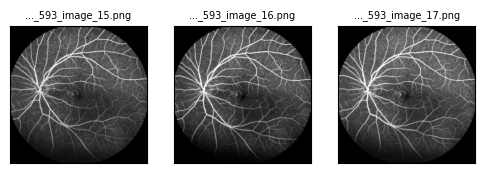

Set: 1


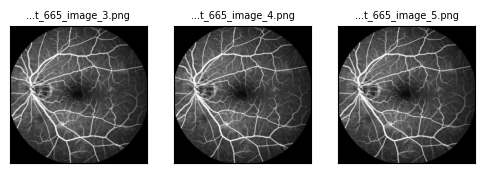

Set: 2


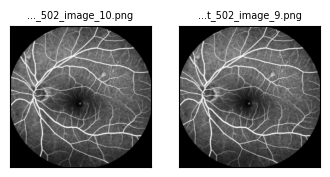

Set: 3


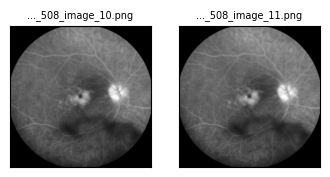

----------------------- dark images ------------------------

Number of examples with this issue: 7
Examples representing most severe instances of this issue:



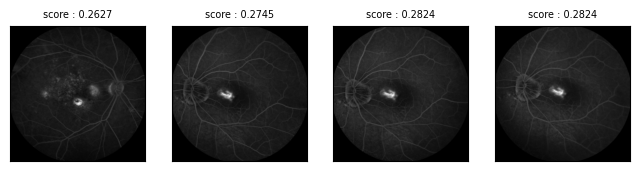

---------------------- blurry images -----------------------

Number of examples with this issue: 1
Examples representing most severe instances of this issue:



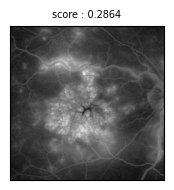

In [11]:
from cleanvision import Imagelab

path = 'ImageProcessing/256FFA'
imagelab = Imagelab(data_path = path)
imagelab.find_issues()
imagelab.report()

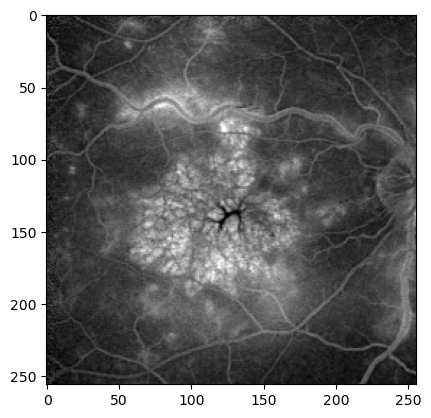

In [12]:
import cv2 as cv
import matplotlib.pyplot as plt

blurry_images = imagelab.issues[imagelab.issues["is_blurry_issue"] == True].sort_values(by=["blurry_score"])
blurry_image_files = blurry_images.index.tolist()

img = cv.imread(blurry_image_files[0])
blur = img.copy()
blur = cv2.GaussianBlur(blur, (0, 0), 2.0)
unsharp = cv2.addWeighted(img, 2.0, blur, -1.0, 0)
cv.imwrite(blurry_image_files[0], unsharp)

plt.imshow(unsharp, cmap='grey')

In [13]:
import cv2 as cv

blurry_images = imagelab.issues[imagelab.issues["is_blurry_issue"] == True].sort_values(by=["blurry_score"])
blurry_image_files = blurry_images.index.tolist()

for image in blurry_image_files:
    img = cv.imread(blurry_image_files[0])
    blur = img.copy()
    blur = cv2.GaussianBlur(blur, (0, 0), 2.0)
    unsharp = cv2.addWeighted(img, 2.0, blur, -1.0, 0)
    cv.imwrite(blurry_image_files[0], unsharp)

In [14]:
import cv2 as cv
from PIL import Image, ImageEnhance

dark_images = imagelab.issues[imagelab.issues["is_dark_issue"] == True].sort_values(by=["blurry_score"])
dark_image_files = dark_images.index.tolist()

for image in dark_image_files:
    img = cv.imread(image)
    bright = cv2.convertScaleAbs(img, alpha=1.0, beta=50)
    cv.imwrite(image, bright)

Reading images from /home/FYP/tsajoto001/OCTA/256FFA
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing scores:   0%|          | 0/937 [00:00<?, ?it/s]

Computing hashes:   0%|          | 0/937 [00:00<?, ?it/s]

Issue checks completed. 66 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | near_duplicates  |           66 |
|  1 | dark             |            0 |
|  2 | light            |            0 |
|  3 | low_information  |            0 |
|  4 | odd_aspect_ratio |            0 |
|  5 | blurry           |            0 |
|  6 | grayscale        |            0 |
|  7 | odd_size         |            0 |
|  8 | exact_duplicates |            0 | 

------------------ near_duplicates images ------------------

Number of examples with this issue: 66
Examples representing most severe instances of this issue:

Set: 0


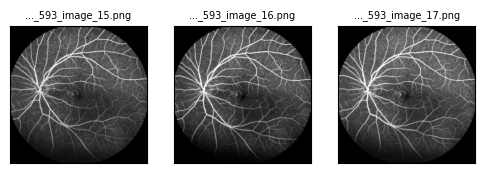

Set: 1


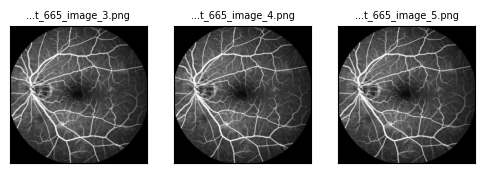

Set: 2


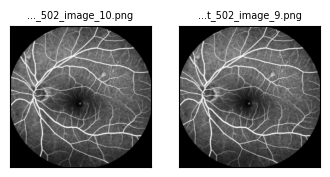

Set: 3


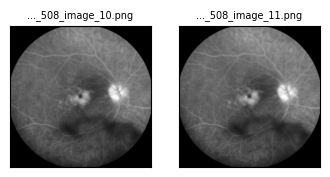

In [15]:
from cleanvision import Imagelab

path = '256FFA'
imagelab = Imagelab(data_path = path)
imagelab.find_issues()
imagelab.report()

Images with issues or near/exact duplicates, blurriness and grayscale are ignored as they are intended in the respective images.

# Color Fundus Processing

In [2]:
from pathlib import Path

np = Path('ImageProcessing/CFP/0_Normal')
ncount = len([item for item in np.iterdir() if item.is_file()])

dp = Path('ImageProcessing/CFP/1_DR')
dcount = len([item for item in dp.iterdir() if item.is_file()])

rp = Path('ImageProcessing/CFP/3_RVO')
rcount = len([item for item in rp.iterdir() if item.is_file()])

count = ncount + dcount + rcount

print(count)

369


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('ImageProcessing/Training_Set/Training_Set/RFMiD_Training_Labels.csv')

In [4]:
df.head()

,ID,Disease_Risk,DR,ARMD,MH,DN,MYA,BRVO,TSLN,ERM,...,CME,PTCR,CF,VH,MCA,VS,BRAO,PLQ,HPED,CL
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
#count number of DR images
print(len(df[df['DR'] == 1]))

376


In [13]:
#no of rvo
rcount = ((df['BRVO'] == 1) | (df['CRVO'] == 1)).sum()
print(rcount)

101


In [16]:
#no of normal
print((df.drop(columns=['ID', 'Disease_Risk']) == 0).all(axis=1).sum())

401


In [ ]:
#1. extract images to seperate folder
#2. check if cleaning/cropping is needed
#3. conduct data splitting

In [17]:
from pathlib import Path

folder_name = 'selectedCF'
Path(folder_name).mkdir(parents=True, exist_ok=True)

In [22]:
dr = df[df['DR'] == 1]

,ID,Disease_Risk,DR,ARMD,MH,DN,MYA,BRVO,TSLN,ERM,...,CME,PTCR,CF,VH,MCA,VS,BRAO,PLQ,HPED,CL
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17,18,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1686,1687,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1692,1693,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1724,1725,1,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1725,1726,1,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
test = df.iloc[[0]]
test

,ID,Disease_Risk,DR,ARMD,MH,DN,MYA,BRVO,TSLN,ERM,...,CME,PTCR,CF,VH,MCA,VS,BRAO,PLQ,HPED,CL
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
test['ARMD']

0    0
Name: ARMD, dtype: int64

In [36]:
import shutil
import os
import cv2
from pathlib import Path

cf = {}
source = 'ImageProcessing/Training_Set/Training_Set/Training/'
dest = 'ImageProcessing/256CF/'

for i in range(len(df)):
    dx = {}
    img = df.iloc[[i]]
    ID = str(img['ID'].values[0])
    if img['DR'].values[0] == 1:
        dx = {ID : [1, 0, 0, 0, 0]}
    elif img['BRVO'].values[0] == 1 or img['CRVO'].values[0] == 1:
        dx = {ID : [0, 0, 1, 0, 0]}
    elif (img.iloc[:, 2:] == 0).all(axis=1).values[0]:
        dx = {ID: [0, 0, 0, 0, 0]} 

    if len(dx) > 0:
        cf.update(dx)
        # print(dx)
        # path = source + ID + '.png'
        # print(path)
        image = cv2.imread(path)
        image = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)
        image = cv2.normalize(image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
        target = dest + ID + '.png'
        print(target)
        cv2.imwrite(target, image)

selectedCF/1.png
selectedCF/2.png
selectedCF/3.png
selectedCF/5.png
selectedCF/10.png
selectedCF/16.png
selectedCF/17.png
selectedCF/18.png
selectedCF/19.png
selectedCF/20.png
selectedCF/21.png
selectedCF/26.png
selectedCF/28.png
selectedCF/34.png
selectedCF/36.png
selectedCF/37.png
selectedCF/38.png
selectedCF/39.png
selectedCF/41.png
selectedCF/42.png
selectedCF/43.png
selectedCF/44.png
selectedCF/49.png
selectedCF/50.png
selectedCF/58.png
selectedCF/59.png
selectedCF/61.png
selectedCF/62.png
selectedCF/64.png
selectedCF/68.png
selectedCF/70.png
selectedCF/71.png
selectedCF/74.png
selectedCF/80.png
selectedCF/81.png
selectedCF/83.png
selectedCF/85.png
selectedCF/86.png
selectedCF/90.png
selectedCF/91.png
selectedCF/92.png
selectedCF/93.png
selectedCF/94.png
selectedCF/97.png
selectedCF/98.png
selectedCF/101.png
selectedCF/102.png
selectedCF/104.png
selectedCF/105.png
selectedCF/106.png
selectedCF/111.png
selectedCF/112.png
selectedCF/115.png
selectedCF/116.png
selectedCF/117.png
sele

In [37]:
from cleanvision import Imagelab

path = '256CF'
imagelab = Imagelab(data_path = path)
imagelab.find_issues()
imagelab.report()

Reading images from /home/FYP/tsajoto001/OCTA/selectedCF
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing scores:   0%|          | 0/876 [00:00<?, ?it/s]

Computing hashes:   0%|          | 0/876 [00:00<?, ?it/s]

Issue checks completed. 876 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Removing exact_duplicates from potential issues in the dataset as it exceeds max_prevalence=0.5 
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  1 | dark             |            0 |
|  2 | light            |            0 |
|  3 | low_information  |            0 |
|  4 | odd_aspect_ratio |            0 |
|  5 | blurry           |            0 |
|  6 | grayscale        |            0 |
|  7 | odd_size         |            0 |
|  8 | near_duplicates  |            0 | 



# Data Splitting

In [35]:
from pathlib import Path

folder_name = 'ML'
Path(folder_name).mkdir(parents=True, exist_ok=True)

In [35]:
from pathlib import Path

folder_name = 'ML/train'
Path(folder_name).mkdir(parents=True, exist_ok=True)

In [35]:
from pathlib import Path

folder_name = 'ML/test'
Path(folder_name).mkdir(parents=True, exist_ok=True)

In [36]:
from pathlib import Path

paths = ['ML/train/OCTA', 'ML/train/FFA', 'ML/train/CF', 'ML/test/OCTA', 'ML/test/FFA', 'ML/test/CF']

for path in paths:
    Path(path).mkdir(parents=True, exist_ok=True)

In [37]:
import random
import shutil
import os
from pathlib import Path

dest = ['ML/train/OCTA', 'ML/test/OCTA']
weights = [0.8, 0.2]

source = 'ImageProcessing/256UWOCTA'
for img in Path(source).iterdir():
    if img.suffix == '.png':
        selection = random.choices(dest, weights=weights, k=1)
        path = source + '/' + os.path.basename(img)
        shutil.copy2(path, selection[0])

In [38]:
import random
import shutil
import os
from pathlib import Path

dest = ['ML/train/FFA', 'ML/test/FFA']
weights = [0.8, 0.2]

source = '256FFA'
for img in Path(source).iterdir():
    if img.suffix == '.png':
        selection = random.choices(dest, weights=weights, k=1)
        path = source + '/' + os.path.basename(img)
        shutil.copy2(path, selection[0])

In [43]:
import random
import shutil
import os
from pathlib import Path

random.seed(42)
dest = ['ML/train/CF', 'ML/test/CF']
weights = [0.8, 0.2]

source = 'ImageProcessing/256CF'
for img in Path(source).iterdir():
    if img.suffix == '.png':
        selection = random.choices(dest, weights=weights, k=1)
        path = source + '/' + os.path.basename(img)
        shutil.copy2(path, selection[0])

In [39]:
from pathlib import Path

p = Path('ML/train/OCTA')

count = len([item for item in p.iterdir() if item.is_file()])
print(count)

763


In [40]:
from pathlib import Path

p = Path('ML/train/FFA')

count = len([item for item in p.iterdir() if item.is_file()])
print(count)

759


In [41]:
from pathlib import Path

p = Path('ML/test/OCTA')

count = len([item for item in p.iterdir() if item.is_file()])
print(count)

174


In [42]:
from pathlib import Path

p = Path('ML/test/FFA')

count = len([item for item in p.iterdir() if item.is_file()])
print(count)

178


In [44]:
from pathlib import Path

p = Path('ML/train/CF')

count = len([item for item in p.iterdir() if item.is_file()])
print(count)

696


In [45]:
from pathlib import Path

p = Path('ML/test/CF')

count = len([item for item in p.iterdir() if item.is_file()])
print(count)

180


# Counting

In [7]:
import json

with open('ImageProcessing/uwocta.json', 'r') as file:
    uwocta = json.load(file)

In [8]:
import os
from pathlib import Path

healthy_octa_train = 0
rvo_octa_train = 0
dr_octa_train = 0

for img in Path('ML/train/OCTA').iterdir():
    if img.suffix == '.png':
        octa = str(os.path.basename(img))
        dx = uwocta[octa]
        if 1 in dx:
            if dx[0] == 1:
                dr_octa_train = dr_octa_train + 1
            if dx[2] == 1:
                rvo_octa_train = rvo_octa_train + 1
        else:
            healthy_octa_train = healthy_octa_train + 1

In [10]:
import os
from pathlib import Path

healthy_octa_test = 0
rvo_octa_test = 0
dr_octa_test = 0

for img in Path('ML/test/OCTA').iterdir():
    if img.suffix == '.png':
        octa = str(os.path.basename(img))
        dx = uwocta[octa]
        if 1 in dx:
            if dx[0] == 1:
                dr_octa_test = dr_octa_test + 1
            if dx[2] == 1:
                rvo_octa_test = rvo_octa_test + 1
        else:
            healthy_octa_test = healthy_octa_test + 1

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv('Training_Set/Training_Set/RFMiD_Training_Labels.csv')

In [12]:
df.head()

,ID,Disease_Risk,DR,ARMD,MH,DN,MYA,BRVO,TSLN,ERM,...,CME,PTCR,CF,VH,MCA,VS,BRAO,PLQ,HPED,CL
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
len(df)

1920

In [14]:
print(df.loc[8, 'DR'])

0


In [15]:
import os
from pathlib import Path

healthy_cf_train = 0
rvo_cf_train = 0
dr_cf_train = 0

for image in Path('ML/train/CF').iterdir():
    if image.suffix == '.png':
        img = df.iloc[[int(image.stem)-1]]
        if img['DR'].values[0] == 1:
            dr_cf_train = dr_cf_train + 1
        elif img['BRVO'].values[0] == 1 or img['CRVO'].values[0] == 1:
            rvo_cf_train = rvo_cf_train + 1
        elif (img.iloc[:, 2:] == 0).all(axis=1).values[0]:
            healthy_cf_train = healthy_cf_train + 1

In [17]:
import os
from pathlib import Path

healthy_cf_test = 0
rvo_cf_test = 0
dr_cf_test = 0

for image in Path('ML/test/CF').iterdir():
    if image.suffix == '.png':
        img = df.iloc[[int(image.stem)-1]]
        if img['DR'].values[0] == 1:
            dr_cf_test = dr_cf_test + 1
        elif img['BRVO'].values[0] == 1 or img['CRVO'].values[0] == 1:
            rvo_cf_test = rvo_cf_test + 1
        elif (img.iloc[:, 2:] == 0).all(axis=1).values[0]:
            healthy_cf_test = healthy_cf_test + 1

In [22]:
import os
from pathlib import Path

healthy_ffa_train = 0

for image in Path('ML/train/FFA').iterdir():
    if image.suffix == '.png':
        if 'patient' not in str(image):
            healthy_ffa_train = healthy_ffa_train + 1

print(healthy_ffa_train)

81


In [23]:
import os
from pathlib import Path

healthy_ffa_test = 0

for image in Path('ML/test/FFA').iterdir():
    if image.suffix == '.png':
        if 'patient' not in str(image):
            healthy_ffa_test = healthy_ffa_test + 1

print(healthy_ffa_test)

18


In [18]:
print('healthy cf images in train: ', healthy_cf_train)
print('dr cf images in train: ', dr_cf_train)
print('rvo cf images in train: ', rvo_cf_train)

healthy cf images in train:  325
dr cf images in train:  287
rvo cf images in train:  84


In [19]:
print('healthy octa images in train: ', healthy_octa_train)
print('dr octa images in train: ', dr_octa_train)
print('rvo octa images in train: ', rvo_octa_train)

healthy octa images in train:  342
dr octa images in train:  260
rvo octa images in train:  85


In [20]:
print('healthy cf images in test: ', healthy_cf_test)
print('dr cf images in test: ', dr_cf_test)
print('rvo cf images in test: ', rvo_cf_test)

healthy cf images in test:  76
dr cf images in test:  89
rvo cf images in test:  15


In [21]:
print('healthy octa images in test: ', healthy_octa_test)
print('dr octa images in test: ', dr_octa_test)
print('rvo octa images in test: ', rvo_octa_test)

healthy octa images in test:  86
dr octa images in test:  59
rvo octa images in test:  19
